In [63]:
import numpy as np
import tqdm
import ipywidgets
import matplotlib.pyplot as plt
from scipy.constants import k, e
from scipy.interpolate import RegularGridInterpolator
import sys
import yt
sys.path.append('../../theory/sedov_theory/python/')
from sedov_theory import SedovTalorProblem
from analysis_tool import CastroSimulation

In [78]:
ds_full_nodiff = yt.load('../run/1T_no_diff/plt_1d_*')
ds_full_diff = yt.load('../run/1T_yes_diff/plt_1d_*')

labels = ['1T, without diffusion', '1T, with diffusion']


In [79]:
def extract_total_energy(ds_full):
    E_tot = []
    time = []
    for ds in tqdm.tqdm(ds_full):
        ad0 = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=ds.domain_dimensions)
        E = np.array(ad0['rho_E'].to_ndarray().squeeze())
        r = np.array(np.linspace(ds.domain_left_edge[0], ds.domain_right_edge[0], ds.domain_dimensions[0]+1))
        E_tot.append( (np.pi*(r[1:]**2 - r[:-1]**2)*E).sum() )
        time.append(float(ds.current_time))
    return np.array(time), np.array(E_tot)


100%|██████████| 578/578 [00:32<00:00, 17.77it/s]
/var/folders/_d/m96lcmy90_b9sc5fmhg3d_br0000gn/T/ipykernel_78552/3547965222.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


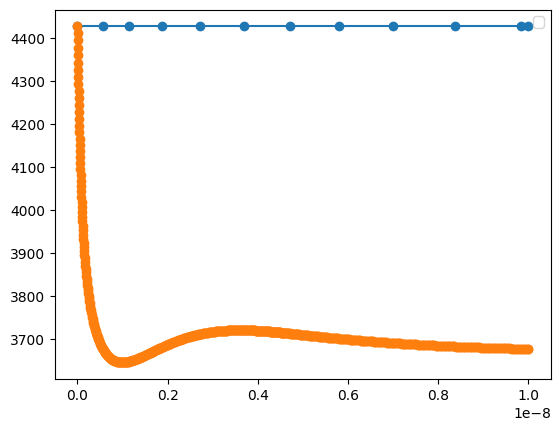

In [80]:
for ds_full in [ds_full_nodiff, ds_full_diff]:
    time, E_tot = extract_total_energy(ds_full)
    plt.plot(time, E_tot, '-o')
plt.legend()
plt.show()